# **Active Learning**

- Author: Tales Miguel Machado Pereira
- RA: 140247
- Professor: Dr. Marcos Quiles

## **Deliverable 5 Instructions:**

### **Consider the "algorithm" below for the next assignment:**

- Sort the molecules of the training set by the number of atoms
- Select the top 1% of the smallest molecules (initial_training)
- Train the initial models with this subset (initial_training)

acc = [evaluate_model(test_set)]
remaining_training = training - initial_training
for step in range(size(remaining_training)):
     sample_active = active_selection(remaining_training)
     initial_training += sample_active # adding the selected molecule to the training set
     remaining_training -= sample_active # excluding this molecule from the pool
     retraing_models()
     acc.append(evaluate_model(test_set))


The random selection must be included in the same loop. It means, after training the initial models, you must select a sample using the active learning approach and a sample using a random approach. The models must be updated with the new dataset and evaluated again.

### **First guidance**
- Active Learning: Committee-base approach
    - Using the baseline model established in step III: train multiple regressors (with different seed and small hyperparameters modifications)
    - Use a subset of 1% of the training data to build the initial models
    - At each step of the active learning loop, select new samples from the training data (the number of samples must be evaluated – select a small number)
    - Update the model with the new samples
    - Plot a graph showing the Error measurement versus the percentage of samples used for training
    - Compare the active learning results with a passive (random) selection
  
### Summary of requirements:

- Sort the molecules in the training set by the number of atoms.

- Select the top 1% of the smallest molecules (initial_training).

- Train the initial models with this subset.

- Loop where:

    - Evaluate the model on the test set.

    - Select 1 sample (up to 5) using active learning (sample_active).

    - Select 1 sample (up to 5) using random selection (sample_random).

    - Add the samples to the initial_training.

    - Remove from the remaining_training.

    - Retrain the models.

    - Repeat until the remaining_training is exhausted.

### **1. Setup**

Import libraries and configure environment

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from rdkit import Chem
from rdkit.Chem import AllChem

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from dscribe.descriptors import CoulombMatrix
from ase import Atoms

from tqdm.auto import tqdm
import random
import time

random.seed(42)
np.random.seed(42)

### **2. Load QM9 Dataset and Split**

Load the full QM9 dataset, create target variable, and split into train/test sets

In [6]:
qm9_df = pd.read_csv('qm9_complete_dataset.csv')

qm9_df['bandgap'] = qm9_df['lumo_energy'] - qm9_df['homo_energy']

train_df, test_df = train_test_split(qm9_df, test_size=0.2, random_state=42)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

### **3. Sort Training Set by Number of Atoms**

Sort molecules in training set by number of atoms and select top 1% smallest molecules for initial training

In [7]:
def count_atoms_from_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return 0
    return mol.GetNumAtoms()

train_df['num_atoms'] = train_df['canonical_smiles'].apply(count_atoms_from_smiles)

train_df = train_df.sort_values('num_atoms').reset_index(drop=True)

initial_size = int(len(train_df) * 0.01)
initial_training = train_df.iloc[:initial_size].copy()
remaining_training = train_df.iloc[initial_size:].copy()

In [13]:
print(f"Total QM9 samples: {len(qm9_df)}")
print(f"Training set size (80%): {len(train_df)}")
print(f"Test set size (20%): {len(test_df)}")
print("-" * 30)
print(f"Initial training size (1% of Train): {len(initial_training)}")
print(f"Remaining pool size: {len(remaining_training)}")

Total QM9 samples: 133885
Training set size (80%): 107108
Test set size (20%): 26777
------------------------------
Initial training size (1% of Train): 1071
Remaining pool size: 106037


### **4. Compute Test Set Features**

Convert test set SMILES to 3D structures and compute EV-CM features once

In [8]:
cm = CoulombMatrix(n_atoms_max=29, permutation='eigenspectrum')

def smiles_to_ase(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    
    mol_h = Chem.AddHs(mol)
    result = AllChem.EmbedMolecule(mol_h, randomSeed=42)
    
    if result == -1 or mol_h.GetNumConformers() == 0:
        return None
    
    conf = mol_h.GetConformer()
    positions = conf.GetPositions()
    symbols = [atom.GetSymbol() for atom in mol_h.GetAtoms()]
    
    return Atoms(symbols=symbols, positions=positions)

test_ase = []
test_valid_idx = []

for idx, smiles in tqdm(enumerate(test_df['canonical_smiles']), total=len(test_df), desc="Converting test set"):
    ase_mol = smiles_to_ase(smiles)
    if ase_mol is not None:
        test_ase.append(ase_mol)
        test_valid_idx.append(idx)

test_df_clean = test_df.iloc[test_valid_idx].reset_index(drop=True)
X_test = cm.create(test_ase, n_jobs=-1)
y_test = test_df_clean['bandgap'].values

scaler = StandardScaler()
X_test_scaled = scaler.fit_transform(X_test)

Converting test set: 100%|██████████| 26777/26777 [01:12<00:00, 368.81it/s]


### **5. Pre-compute Initial Training Features**

Pre-compute EV-CM features for the initial 1% training set to speed up Active Learning loop

In [9]:
from joblib import Parallel, delayed

feature_cache = {}

def process_smiles_wrapper(smiles):
    return smiles_to_ase(smiles)

smiles_list = train_df['canonical_smiles'].tolist()
indices = train_df.index.tolist()
bandgaps = train_df['bandgap'].tolist()

ase_mols = Parallel(n_jobs=-1, verbose=5)(
    delayed(process_smiles_wrapper)(s) for s in smiles_list
)

valid_indices = []
valid_ase_mols = []
valid_y = []

for i, mol in enumerate(ase_mols):
    if mol is not None:
        valid_indices.append(indices[i])
        valid_ase_mols.append(mol)
        valid_y.append(bandgaps[i])

X_all = cm.create(valid_ase_mols, n_jobs=-1)

for i, idx in enumerate(valid_indices):
    feature_cache[idx] = {'X': X_all[i], 'y': valid_y[i]}

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 137 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 704 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 4160 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 4160 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 16832 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-1)]: Done 16832 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-1)]: Done 31808 tasks      | elapsed:    5.5s
[Parallel(n_jobs=-1)]: Done 31808 tasks      | elapsed:    5.5s
[Parallel(n_jobs=-1)]: Done 49088 tasks      | elapsed:    9.0s
[Parallel(n_jobs=-1)]: Done 49088 tasks      | elapsed:    9.0s
[Parallel(n_jobs=-1)]: Done 68672 tasks      | elapsed:   13.1s
[Parallel(n_jobs=-1)]: Done 68672 tasks      | elapsed:   13.1s
[Parallel(n_jobs=-1)]: Done 90560 tasks      | elapsed:   17.6s
[Parallel(n_jobs=-1)]: Done 90560 t

### **6. Committee-Based Active Learning Loop**

Implement parallel Active Learning and Random Selection loops with committee-based uncertainty sampling

In [10]:
import gc

def get_cached_features(indices):
    X_list = []
    y_list = []
    
    for idx in indices:
        X_list.append(feature_cache[idx]['X'])
        y_list.append(feature_cache[idx]['y'])
    
    return np.vstack(X_list), np.array(y_list)

def create_committee(n_models=5):
    committee = []
    
    base_params = {
        'hidden_layer_sizes': (128, 64),
        'activation': 'relu',
        'alpha': 0.0001,
        'learning_rate_init': 0.001,
        # 'max_iter': 200,
        'early_stopping': False,
        'validation_fraction': 0.1
    }
    
    for i in range(n_models):
        model = MLPRegressor(
            hidden_layer_sizes=base_params['hidden_layer_sizes'],
            activation=base_params['activation'],
            alpha=base_params['alpha'] + i * 0.0002,
            learning_rate_init=base_params['learning_rate_init'] + i * 0.0005,
            # max_iter=base_params['max_iter'],
            random_state=42 + i,
            early_stopping=base_params['early_stopping']
        )
        committee.append(model)
    
    return committee

def train_committee(committee, X_train, y_train):
    for model in committee:
        model.fit(X_train, y_train)
    return committee

def committee_uncertainty(committee, X_pool):
    predictions = np.array([model.predict(X_pool) for model in committee])
    uncertainties = np.var(predictions, axis=0)
    return uncertainties

def select_samples_active(committee, remaining_pool, X_full, idx_map, n_samples=5):
    rows = [idx_map[idx] for idx in remaining_pool.index]
    X_pool = X_full[rows]
    
    X_pool_scaled = scaler.transform(X_pool)
    uncertainties = committee_uncertainty(committee, X_pool_scaled)
    
    most_uncertain_local_idx = np.argsort(uncertainties)[-n_samples:]
    
    selected_indices = [remaining_pool.index[i] for i in most_uncertain_local_idx]
    
    return selected_indices

def select_samples_random(remaining_pool, n_samples=5):
    n_select = min(n_samples, len(remaining_pool))
    return remaining_pool.sample(n=n_select, random_state=None).index.tolist()

def active_learning_loop(initial_train_df, remaining_train_df, query_size=5, target_r2=None):
    results_active = []
    results_random = []
    
    valid_keys = set(feature_cache.keys())
    
    labeled_active_idx = [idx for idx in initial_train_df.index.tolist() if idx in valid_keys]
    unlabeled_active_idx = [idx for idx in remaining_train_df.index.tolist() if idx in valid_keys]
    
    labeled_random_idx = [idx for idx in initial_train_df.index.tolist() if idx in valid_keys]
    unlabeled_random_idx = [idx for idx in remaining_train_df.index.tolist() if idx in valid_keys]
    
    dropped_count = (len(initial_train_df) + len(remaining_train_df)) - (len(labeled_active_idx) + len(unlabeled_active_idx))
    if dropped_count > 0:
        print(f"Warning: {dropped_count} molecules were skipped because their features could not be computed.")
    
    print("Constructing full feature matrix for optimization (one-time cost)...")
    all_indices = labeled_active_idx + unlabeled_active_idx
    X_full, y_full = get_cached_features(all_indices)
    
    if X_full is None:
        raise ValueError("Could not compute features. Ensure cache is populated.")
        
    idx_map = {idx: i for i, idx in enumerate(all_indices)}
    y_full_map = {idx: y for idx, y in zip(all_indices, y_full)}
    print("Full matrix ready. Starting loop...\n")
    
    X_init = X_full[[idx_map[idx] for idx in labeled_active_idx]]
    y_init = np.array([y_full_map[idx] for idx in labeled_active_idx])
    
    X_init_scaled = scaler.transform(X_init)
    
    committee_active = create_committee()
    committee_random = create_committee()
    
    train_committee(committee_active, X_init_scaled, y_init)
    train_committee(committee_random, X_init_scaled, y_init)
    
    y_pred_active = np.mean([model.predict(X_test_scaled) for model in committee_active], axis=0)
    y_pred_random = np.mean([model.predict(X_test_scaled) for model in committee_random], axis=0)
    
    r2_active_0 = r2_score(y_test, y_pred_active)
    rmse_active_0 = np.sqrt(mean_squared_error(y_test, y_pred_active))
    mae_active_0 = mean_absolute_error(y_test, y_pred_active)
    
    r2_random_0 = r2_score(y_test, y_pred_random)
    rmse_random_0 = np.sqrt(mean_squared_error(y_test, y_pred_random))
    mae_random_0 = mean_absolute_error(y_test, y_pred_random)
    
    results_active.append({
        'iteration': 0,
        'n_samples': len(labeled_active_idx),
        'pct_samples': len(labeled_active_idx) / len(train_df) * 100,
        'test_r2': r2_active_0,
        'test_rmse': rmse_active_0,
        'test_mae': mae_active_0
    })
    
    results_random.append({
        'iteration': 0,
        'n_samples': len(labeled_random_idx),
        'pct_samples': len(labeled_random_idx) / len(train_df) * 100,
        'test_r2': r2_random_0,
        'test_rmse': rmse_random_0,
        'test_mae': mae_random_0
    })
    
    print(f"Iteration 0:")
    print(f"  Active Learning  - Samples: {len(labeled_active_idx):5d} ({len(labeled_active_idx)/len(train_df)*100:5.2f}%) | R²: {r2_active_0:.4f} | RMSE: {rmse_active_0:.4f} | MAE: {mae_active_0:.4f}")
    print(f"  Random Selection - Samples: {len(labeled_random_idx):5d} ({len(labeled_random_idx)/len(train_df)*100:5.2f}%) | R²: {r2_random_0:.4f} | RMSE: {rmse_random_0:.4f} | MAE: {mae_random_0:.4f}")
    print()
    
    iteration = 1
    active_reached_target = False
    random_reached_target = False
    
    with tqdm(desc="Active Learning Loop") as pbar:
        while (len(unlabeled_active_idx) >= query_size or len(unlabeled_random_idx) >= query_size):
            
            if not active_reached_target and len(unlabeled_active_idx) >= query_size:
                remaining_pool = train_df.loc[unlabeled_active_idx]
                selected_active = select_samples_active(committee_active, remaining_pool, X_full, idx_map, query_size)
                labeled_active_idx.extend(selected_active)
                unlabeled_active_idx = [idx for idx in unlabeled_active_idx if idx not in selected_active]
            
            if not random_reached_target and len(unlabeled_random_idx) >= query_size:
                selected_random = np.random.choice(unlabeled_random_idx, query_size, replace=False).tolist()
                labeled_random_idx.extend(selected_random)
                unlabeled_random_idx = [idx for idx in unlabeled_random_idx if idx not in selected_random]
            
            current_r2_active = 0.0
            if not active_reached_target:
                X_active = X_full[[idx_map[idx] for idx in labeled_active_idx]]
                y_active = np.array([y_full_map[idx] for idx in labeled_active_idx])
                
                if X_active is not None:
                    X_active_scaled = scaler.transform(X_active)
                    train_committee(committee_active, X_active_scaled, y_active)
                    
                    y_pred_active = np.mean([model.predict(X_test_scaled) for model in committee_active], axis=0)
                    r2_active = r2_score(y_test, y_pred_active)
                    rmse_active = np.sqrt(mean_squared_error(y_test, y_pred_active))
                    mae_active = mean_absolute_error(y_test, y_pred_active)
                    current_r2_active = r2_active
                    
                    results_active.append({
                        'iteration': iteration,
                        'n_samples': len(labeled_active_idx),
                        'pct_samples': len(labeled_active_idx) / len(train_df) * 100,
                        'test_r2': r2_active,
                        'test_rmse': rmse_active,
                        'test_mae': mae_active
                    })
                    
                    if target_r2 is not None and r2_active >= target_r2:
                        active_reached_target = True

            current_r2_random = 0.0
            if not random_reached_target:
                X_random = X_full[[idx_map[idx] for idx in labeled_random_idx]]
                y_random = np.array([y_full_map[idx] for idx in labeled_random_idx])
                
                if X_random is not None:
                    X_random_scaled = scaler.transform(X_random)
                    train_committee(committee_random, X_random_scaled, y_random)
                    
                    y_pred_random = np.mean([model.predict(X_test_scaled) for model in committee_random], axis=0)
                    r2_random = r2_score(y_test, y_pred_random)
                    rmse_random = np.sqrt(mean_squared_error(y_test, y_pred_random))
                    mae_random = mean_absolute_error(y_test, y_pred_random)
                    current_r2_random = r2_random
                    
                    results_random.append({
                        'iteration': iteration,
                        'n_samples': len(labeled_random_idx),
                        'pct_samples': len(labeled_random_idx) / len(train_df) * 100,
                        'test_r2': r2_random,
                        'test_rmse': rmse_random,
                        'test_mae': mae_random
                    })
                    
                    if target_r2 is not None and r2_random >= target_r2:
                        random_reached_target = True

            if iteration % 5 == 0:
                postfix = {}
                if not active_reached_target:
                    postfix['Act_R2'] = f"{current_r2_active:.4f}"
                    postfix['Act_N'] = len(labeled_active_idx)
                if not random_reached_target:
                    postfix['Rnd_R2'] = f"{current_r2_random:.4f}"
                    postfix['Rnd_N'] = len(labeled_random_idx)
                
                pbar.set_postfix(postfix)
            
            pbar.update(1)
            
            gc.collect()
            
            iteration += 1
            
            if active_reached_target and random_reached_target:
                break
    
    return pd.DataFrame(results_active), pd.DataFrame(results_random)

target_r2_baseline = 0.95

results_active_df, results_random_df = active_learning_loop(
    initial_training, 
    remaining_training, 
    query_size=5,
    target_r2=target_r2_baseline
)

Constructing full feature matrix for optimization (one-time cost)...
Full matrix ready. Starting loop...

Iteration 0:
  Active Learning  - Samples:  1071 ( 1.00%) | R²: -9.3927 | RMSE: 0.1529 | MAE: 0.1012
  Random Selection - Samples:  1071 ( 1.00%) | R²: -9.3927 | RMSE: 0.1529 | MAE: 0.1012

Iteration 0:
  Active Learning  - Samples:  1071 ( 1.00%) | R²: -9.3927 | RMSE: 0.1529 | MAE: 0.1012
  Random Selection - Samples:  1071 ( 1.00%) | R²: -9.3927 | RMSE: 0.1529 | MAE: 0.1012



Active Learning Loop: 20829it [129:49:25, 22.44s/it, Act_R2=0.6772, Act_N=105196, Rnd_R2=0.6771, Rnd_N=105196]



Final Results Summary:
--------------------------------------------------
Active Learning: 20830 iterations, Final R²: 0.6725, Final RMSE: 0.0271
Random Selection: 20830 iterations, Final R²: 0.6807, Final RMSE: 0.0268


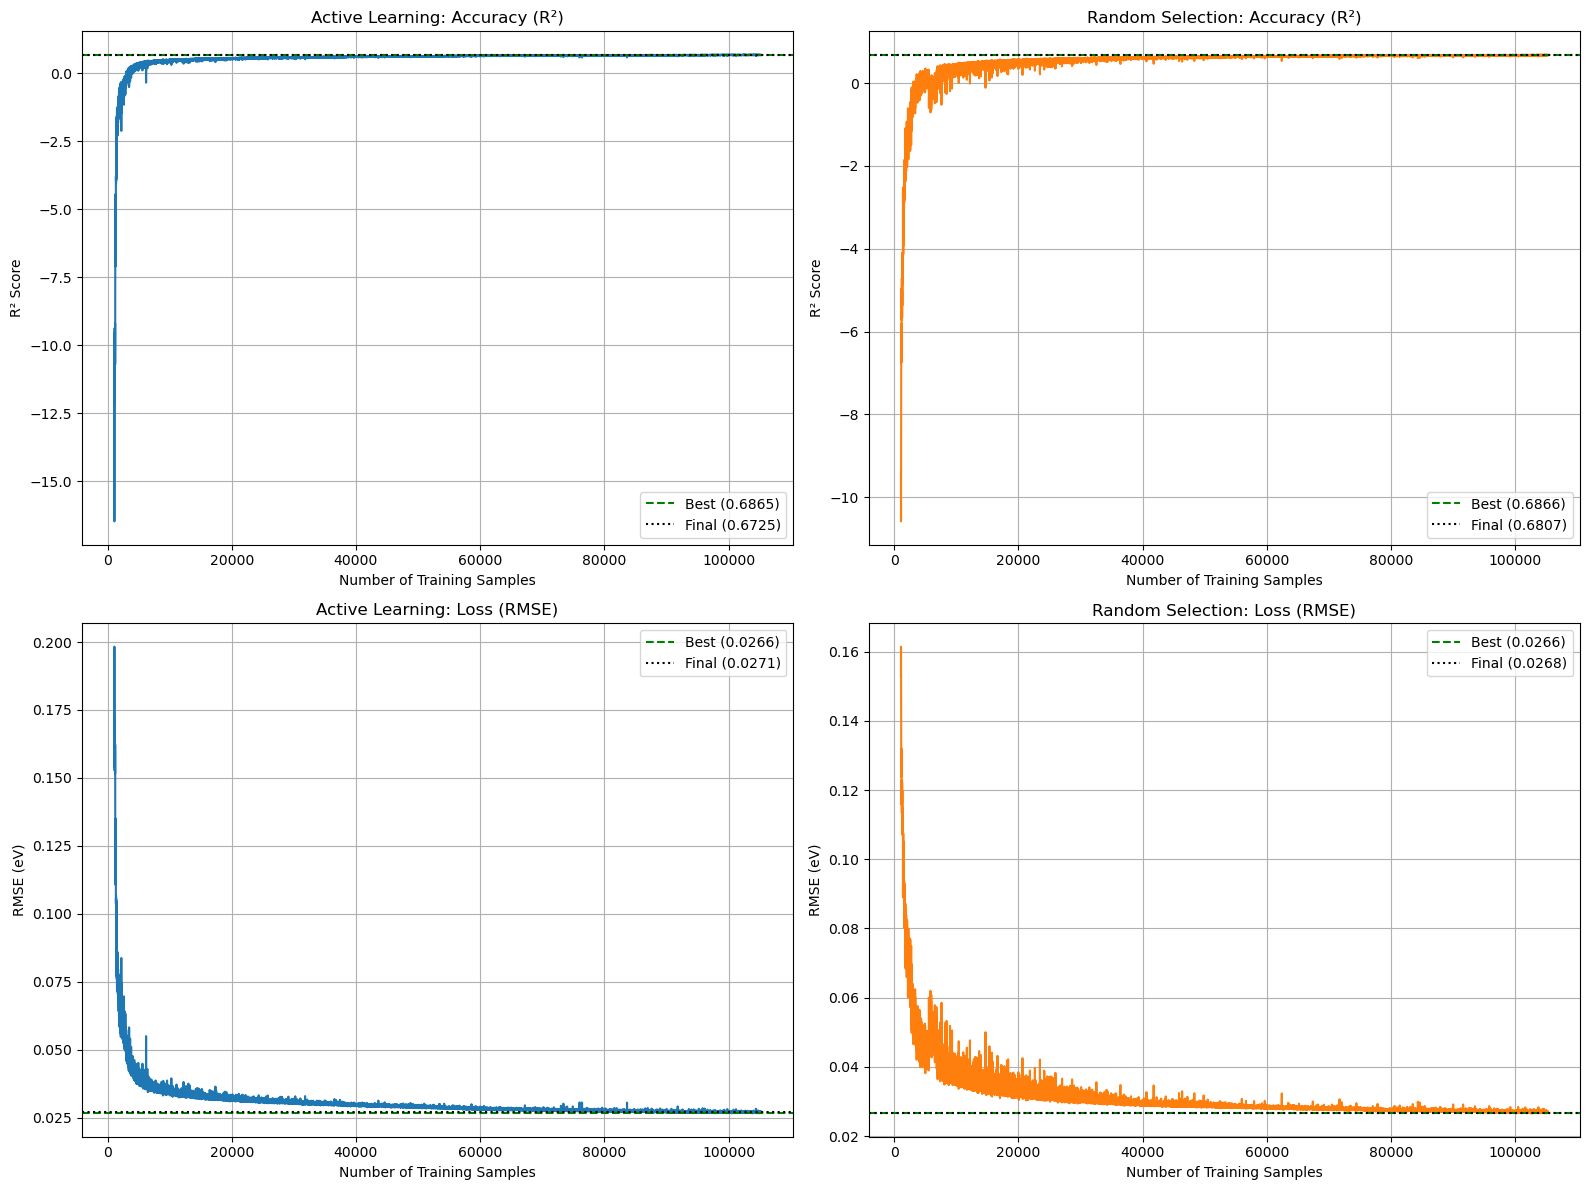

In [58]:
print("Final Results Summary:")

print("-" * 50)

print(f"Active Learning: {len(results_active_df)} iterations, Final R²: {results_active_df['test_r2'].iloc[-1]:.4f}, Final RMSE: {results_active_df['test_rmse'].iloc[-1]:.4f}")

print(f"Random Selection: {len(results_random_df)} iterations, Final R²: {results_random_df['test_r2'].iloc[-1]:.4f}, Final RMSE: {results_random_df['test_rmse'].iloc[-1]:.4f}")

# Calculate Best and Final values
best_r2_active = results_active_df['test_r2'].max()
final_r2_active = results_active_df['test_r2'].iloc[-1]
best_rmse_active = results_active_df['test_rmse'].min()
final_rmse_active = results_active_df['test_rmse'].iloc[-1]

best_r2_random = results_random_df['test_r2'].max()
final_r2_random = results_random_df['test_r2'].iloc[-1]
best_rmse_random = results_random_df['test_rmse'].min()
final_rmse_random = results_random_df['test_rmse'].iloc[-1]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- R² Scores ---

# Active Learning R²
sns.lineplot(data=results_active_df, x='n_samples', y='test_r2', color='tab:blue', ax=axes[0, 0], marker=None, mew=0, markevery=5000)
axes[0, 0].axhline(y=best_r2_active, color='green', linestyle='--', linewidth=1.5, label=f'Best ({best_r2_active:.4f})')
axes[0, 0].axhline(y=final_r2_active, color='black', linestyle=':', linewidth=1.5, label=f'Final ({final_r2_active:.4f})')
axes[0, 0].set_title('Active Learning: Accuracy (R²)')
axes[0, 0].set_xlabel('Number of Training Samples')
axes[0, 0].set_ylabel('R² Score')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Random Selection R²
sns.lineplot(data=results_random_df, x='n_samples', y='test_r2', color='tab:orange', ax=axes[0, 1], marker=None, mew=0, markevery=5000)
axes[0, 1].axhline(y=best_r2_random, color='green', linestyle='--', linewidth=1.5, label=f'Best ({best_r2_random:.4f})')
axes[0, 1].axhline(y=final_r2_random, color='black', linestyle=':', linewidth=1.5, label=f'Final ({final_r2_random:.4f})')
axes[0, 1].set_title('Random Selection: Accuracy (R²)')
axes[0, 1].set_xlabel('Number of Training Samples')
axes[0, 1].set_ylabel('R² Score')
axes[0, 1].legend()
axes[0, 1].grid(True)

# --- RMSE Loss ---

# Active Learning RMSE
sns.lineplot(data=results_active_df, x='n_samples', y='test_rmse', color='tab:blue', ax=axes[1, 0], marker=None, mew=0, markevery=5000)
axes[1, 0].axhline(y=best_rmse_active, color='green', linestyle='--', linewidth=1.5, label=f'Best ({best_rmse_active:.4f})')
axes[1, 0].axhline(y=final_rmse_active, color='black', linestyle=':', linewidth=1.5, label=f'Final ({final_rmse_active:.4f})')
axes[1, 0].set_title('Active Learning: Loss (RMSE)')
axes[1, 0].set_xlabel('Number of Training Samples')
axes[1, 0].set_ylabel('RMSE (eV)')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Random Selection RMSE
sns.lineplot(data=results_random_df, x='n_samples', y='test_rmse', color='tab:orange', ax=axes[1, 1], marker=None, mew=0, markevery=5000)
axes[1, 1].axhline(y=best_rmse_random, color='green', linestyle='--', linewidth=1.5, label=f'Best ({best_rmse_random:.4f})')
axes[1, 1].axhline(y=final_rmse_random, color='black', linestyle=':', linewidth=1.5, label=f'Final ({final_rmse_random:.4f})')
axes[1, 1].set_title('Random Selection: Loss (RMSE)')
axes[1, 1].set_xlabel('Number of Training Samples')
axes[1, 1].set_ylabel('RMSE (eV)')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

Zoom Analysis (0 to 7500 samples):
Active Learning Local Best: R²=0.4808 | RMSE=0.0342
Random Selection Local Best: R²=0.4293 | RMSE=0.0358
----------------------------------------
Global Final Values: AL R²=0.6725 | Random R²=0.6807


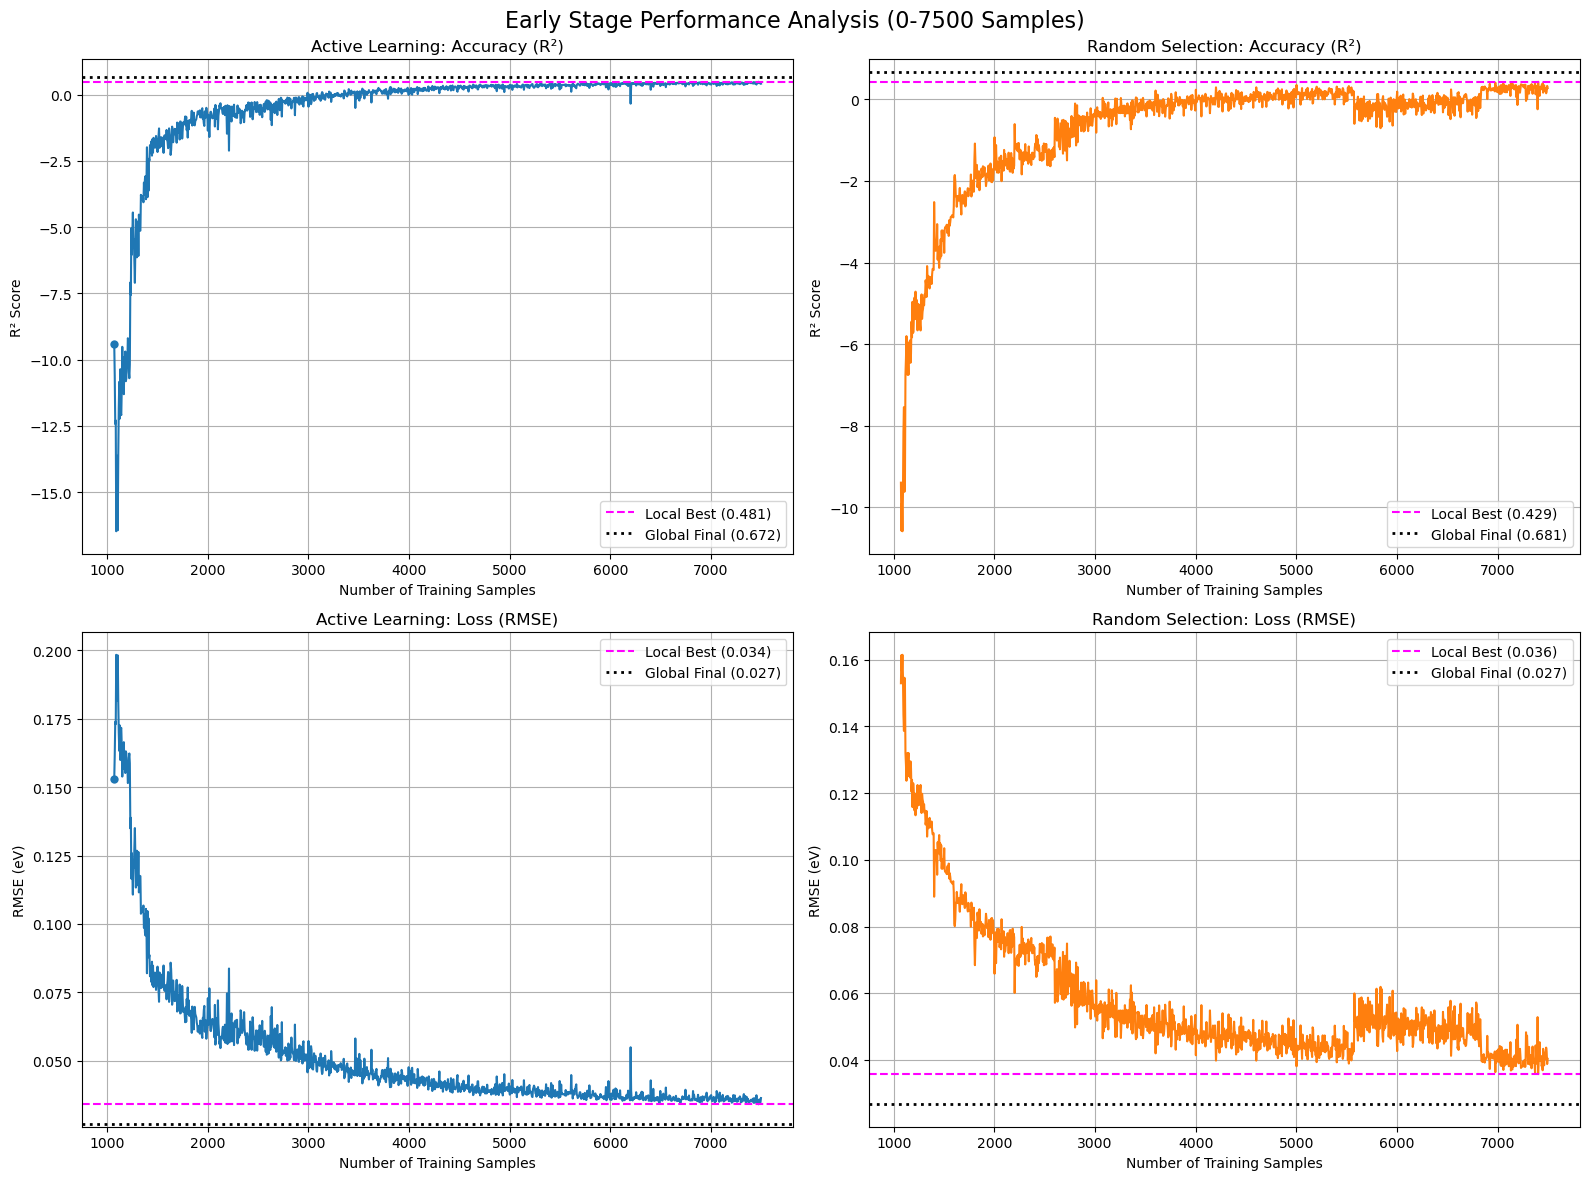

In [44]:
zoom_limit = 7500

# Get Global Final Values (End of Experiment)
final_r2_active = results_active_df['test_r2'].iloc[-1]
final_rmse_active = results_active_df['test_rmse'].iloc[-1]
final_r2_random = results_random_df['test_r2'].iloc[-1]
final_rmse_random = results_random_df['test_rmse'].iloc[-1]

# Filter data
active_zoom = results_active_df[results_active_df['n_samples'] <= zoom_limit]
random_zoom = results_random_df[results_random_df['n_samples'] <= zoom_limit]

# Get Local Best Values (Within Window)
local_best_r2_active = active_zoom['test_r2'].max()
local_best_rmse_active = active_zoom['test_rmse'].min()
local_best_r2_random = random_zoom['test_r2'].max()
local_best_rmse_random = random_zoom['test_rmse'].min()

print(f"Zoom Analysis (0 to {zoom_limit} samples):")
print(f"Active Learning Local Best: R²={local_best_r2_active:.4f} | RMSE={local_best_rmse_active:.4f}")
print(f"Random Selection Local Best: R²={local_best_r2_random:.4f} | RMSE={local_best_rmse_random:.4f}")
print("-" * 40)
print(f"Global Final Values: AL R²={final_r2_active:.4f} | Random R²={final_r2_random:.4f}")

# Create plots - 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'Early Stage Performance Analysis (0-{zoom_limit} Samples)', fontsize=16)

# --- R² Scores ---

# Active Learning R²
sns.lineplot(data=active_zoom, x='n_samples', y='test_r2', color='tab:blue', ax=axes[0, 0], marker='o', mew=0, markevery=5000)
axes[0, 0].set_title('Active Learning: Accuracy (R²)')
axes[0, 0].set_xlabel('Number of Training Samples')
axes[0, 0].set_ylabel('R² Score')
axes[0, 0].grid(True)
axes[0, 0].axhline(y=local_best_r2_active, color='magenta', linestyle='--', label=f'Local Best ({local_best_r2_active:.3f})')
axes[0, 0].axhline(y=final_r2_active, color='black', linestyle=':', linewidth=2, label=f'Global Final ({final_r2_active:.3f})')
axes[0, 0].legend()

# Random Selection R²
sns.lineplot(data=random_zoom, x='n_samples', y='test_r2', color='tab:orange', ax=axes[0, 1], marker='x', mew=0, markevery=5000)
axes[0, 1].set_title('Random Selection: Accuracy (R²)')
axes[0, 1].set_xlabel('Number of Training Samples')
axes[0, 1].set_ylabel('R² Score')
axes[0, 1].grid(True)
axes[0, 1].axhline(y=local_best_r2_random, color='magenta', linestyle='--', label=f'Local Best ({local_best_r2_random:.3f})')
axes[0, 1].axhline(y=final_r2_random, color='black', linestyle=':', linewidth=2, label=f'Global Final ({final_r2_random:.3f})')
axes[0, 1].legend()

# --- RMSE Loss ---

# Active Learning RMSE
sns.lineplot(data=active_zoom, x='n_samples', y='test_rmse', color='tab:blue', ax=axes[1, 0], marker='o', mew=0, markevery=5000)
axes[1, 0].set_title('Active Learning: Loss (RMSE)')
axes[1, 0].set_xlabel('Number of Training Samples')
axes[1, 0].set_ylabel('RMSE (eV)')
axes[1, 0].grid(True)
axes[1, 0].axhline(y=local_best_rmse_active, color='magenta', linestyle='--', label=f'Local Best ({local_best_rmse_active:.3f})')
axes[1, 0].axhline(y=final_rmse_active, color='black', linestyle=':', linewidth=2, label=f'Global Final ({final_rmse_active:.3f})')
axes[1, 0].legend()

# Random Selection RMSE
sns.lineplot(data=random_zoom, x='n_samples', y='test_rmse', color='tab:orange', ax=axes[1, 1], marker='x', mew=0, markevery=5000)
axes[1, 1].set_title('Random Selection: Loss (RMSE)')
axes[1, 1].set_xlabel('Number of Training Samples')
axes[1, 1].set_ylabel('RMSE (eV)')
axes[1, 1].grid(True)
axes[1, 1].axhline(y=local_best_rmse_random, color='magenta', linestyle='--', label=f'Local Best ({local_best_rmse_random:.3f})')
axes[1, 1].axhline(y=final_rmse_random, color='black', linestyle=':', linewidth=2, label=f'Global Final ({final_rmse_random:.3f})')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

Performance at 1996.0 Active Learning samples:
  R²: -0.7261 | RMSE: 0.0623
----------------------------------------
Random Selection needed:
  R²: 2201.0 samples
  RMSE: 2201.0 samples
----------------------------------------
Global Final Values (End of Experiment):
  AL Final R²: 0.6725 | Random Final R²: 0.6807


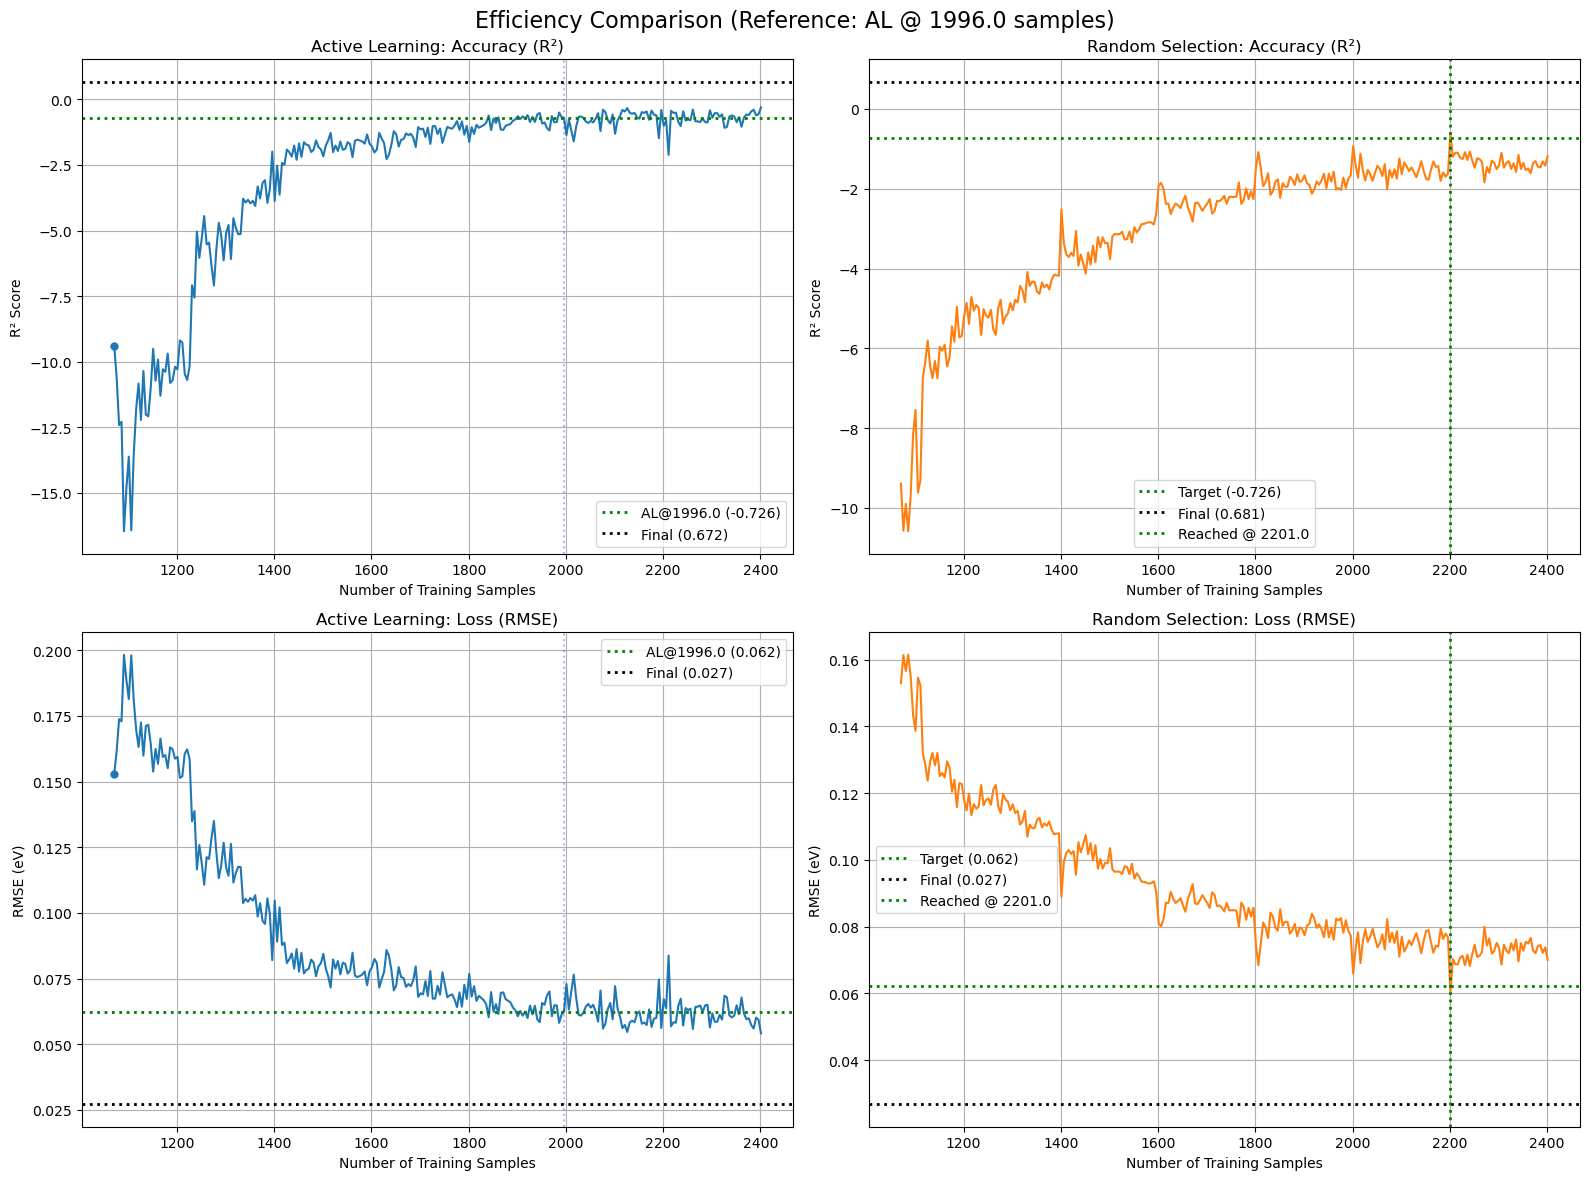

In [37]:
# --- Efficiency Analysis (AL @ 2000 samples vs Random) ---

ref_limit = 2000

# 1. Get Reference Values (Active Learning at ~2000 samples)
al_ref_row = results_active_df[results_active_df['n_samples'] <= ref_limit].iloc[-1]
ref_r2 = al_ref_row['test_r2']
ref_rmse = al_ref_row['test_rmse']
ref_samples = al_ref_row['n_samples']

# 2. Get Global Final Values (End of Experiment)
final_r2_active = results_active_df['test_r2'].iloc[-1]
final_rmse_active = results_active_df['test_rmse'].iloc[-1]
final_r2_random = results_random_df['test_r2'].iloc[-1]
final_rmse_random = results_random_df['test_rmse'].iloc[-1]

# 3. Find when Random Selection matches the Reference performance
# For R² (higher is better)
rnd_r2_match = results_random_df[results_random_df['test_r2'] >= ref_r2]
rnd_samples_r2 = rnd_r2_match.iloc[0]['n_samples'] if not rnd_r2_match.empty else None

# For RMSE (lower is better)
rnd_rmse_match = results_random_df[results_random_df['test_rmse'] <= ref_rmse]
rnd_samples_rmse = rnd_rmse_match.iloc[0]['n_samples'] if not rnd_rmse_match.empty else None

# 4. Determine Plot Range
# Show enough to see the random intersection
max_x = ref_limit
if rnd_samples_r2: max_x = max(max_x, rnd_samples_r2)
if rnd_samples_rmse: max_x = max(max_x, rnd_samples_rmse)
plot_limit = max_x + 200

# Filter data for plots
al_data = results_active_df[results_active_df['n_samples'] <= plot_limit]
rnd_data = results_random_df[results_random_df['n_samples'] <= plot_limit]

print(f"Performance at {ref_samples} Active Learning samples:")
print(f"  R²: {ref_r2:.4f} | RMSE: {ref_rmse:.4f}")
print("-" * 40)
print(f"Random Selection needed:")
print(f"  R²: {rnd_samples_r2} samples" if rnd_samples_r2 else "  R²: Not reached in observed range")
print(f"  RMSE: {rnd_samples_rmse} samples" if rnd_samples_rmse else "  RMSE: Not reached in observed range")
print("-" * 40)
print(f"Global Final Values (End of Experiment):")
print(f"  AL Final R²: {final_r2_active:.4f} | Random Final R²: {final_r2_random:.4f}")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'Efficiency Comparison (Reference: AL @ {ref_samples} samples)', fontsize=16)

# --- R² Scores ---

# Active Learning
sns.lineplot(data=al_data, x='n_samples', y='test_r2', color='tab:blue', ax=axes[0,0], marker='o', mew=0, markevery=5000)
axes[0,0].axhline(y=ref_r2, color='green', linestyle=':', linewidth=2, label=f'AL@{ref_samples} ({ref_r2:.3f})')
axes[0,0].axhline(y=final_r2_active, color='black', linestyle=':', linewidth=2, label=f'Final ({final_r2_active:.3f})')
axes[0,0].axvline(x=ref_samples, color='blue', linestyle=':', alpha=0.3)
axes[0,0].set_title('Active Learning: Accuracy (R²)')
axes[0,0].set_xlabel('Number of Training Samples')
axes[0,0].set_ylabel('R² Score')
axes[0,0].legend()
axes[0,0].grid(True)

# Random Selection
sns.lineplot(data=rnd_data, x='n_samples', y='test_r2', color='tab:orange', ax=axes[0,1], marker='x', mew=0, markevery=5000)
axes[0,1].axhline(y=ref_r2, color='green', linestyle=':', linewidth=2, label=f'Target ({ref_r2:.3f})')
axes[0,1].axhline(y=final_r2_random, color='black', linestyle=':', linewidth=2, label=f'Final ({final_r2_random:.3f})')
if rnd_samples_r2:
    axes[0,1].axvline(x=rnd_samples_r2, color='green', linestyle=':', linewidth=2, label=f'Reached @ {rnd_samples_r2}')
axes[0,1].set_title('Random Selection: Accuracy (R²)')
axes[0,1].set_xlabel('Number of Training Samples')
axes[0,1].set_ylabel('R² Score')
axes[0,1].legend()
axes[0,1].grid(True)

# --- RMSE Loss ---

# Active Learning
sns.lineplot(data=al_data, x='n_samples', y='test_rmse', color='tab:blue', ax=axes[1,0], marker='o', mew=0, markevery=5000)
axes[1,0].axhline(y=ref_rmse, color='green', linestyle=':', linewidth=2, label=f'AL@{ref_samples} ({ref_rmse:.3f})')
axes[1,0].axhline(y=final_rmse_active, color='black', linestyle=':', linewidth=2, label=f'Final ({final_rmse_active:.3f})')
axes[1,0].axvline(x=ref_samples, color='blue', linestyle=':', alpha=0.3)
axes[1,0].set_title('Active Learning: Loss (RMSE)')
axes[1,0].set_xlabel('Number of Training Samples')
axes[1,0].set_ylabel('RMSE (eV)')
axes[1,0].legend()
axes[1,0].grid(True)

# Random Selection
sns.lineplot(data=rnd_data, x='n_samples', y='test_rmse', color='tab:orange', ax=axes[1,1], marker='x', mew=0, markevery=5000)
axes[1,1].axhline(y=ref_rmse, color='green', linestyle=':', linewidth=2, label=f'Target ({ref_rmse:.3f})')
axes[1,1].axhline(y=final_rmse_random, color='black', linestyle=':', linewidth=2, label=f'Final ({final_rmse_random:.3f})')
if rnd_samples_rmse:
    axes[1,1].axvline(x=rnd_samples_rmse, color='green', linestyle=':', linewidth=2, label=f'Reached @ {rnd_samples_rmse}')
axes[1,1].set_title('Random Selection: Loss (RMSE)')
axes[1,1].set_xlabel('Number of Training Samples')
axes[1,1].set_ylabel('RMSE (eV)')
axes[1,1].legend()
axes[1,1].grid(True)

plt.tight_layout()
plt.show()

Window Analysis (20000 to 40000 samples):
Active Learning Local Best: R²=0.6228 | RMSE=0.0291
Random Selection Local Best: R²=0.6336 | RMSE=0.0287
----------------------------------------
Global Final Values: AL R²=0.6725 | Random R²=0.6807


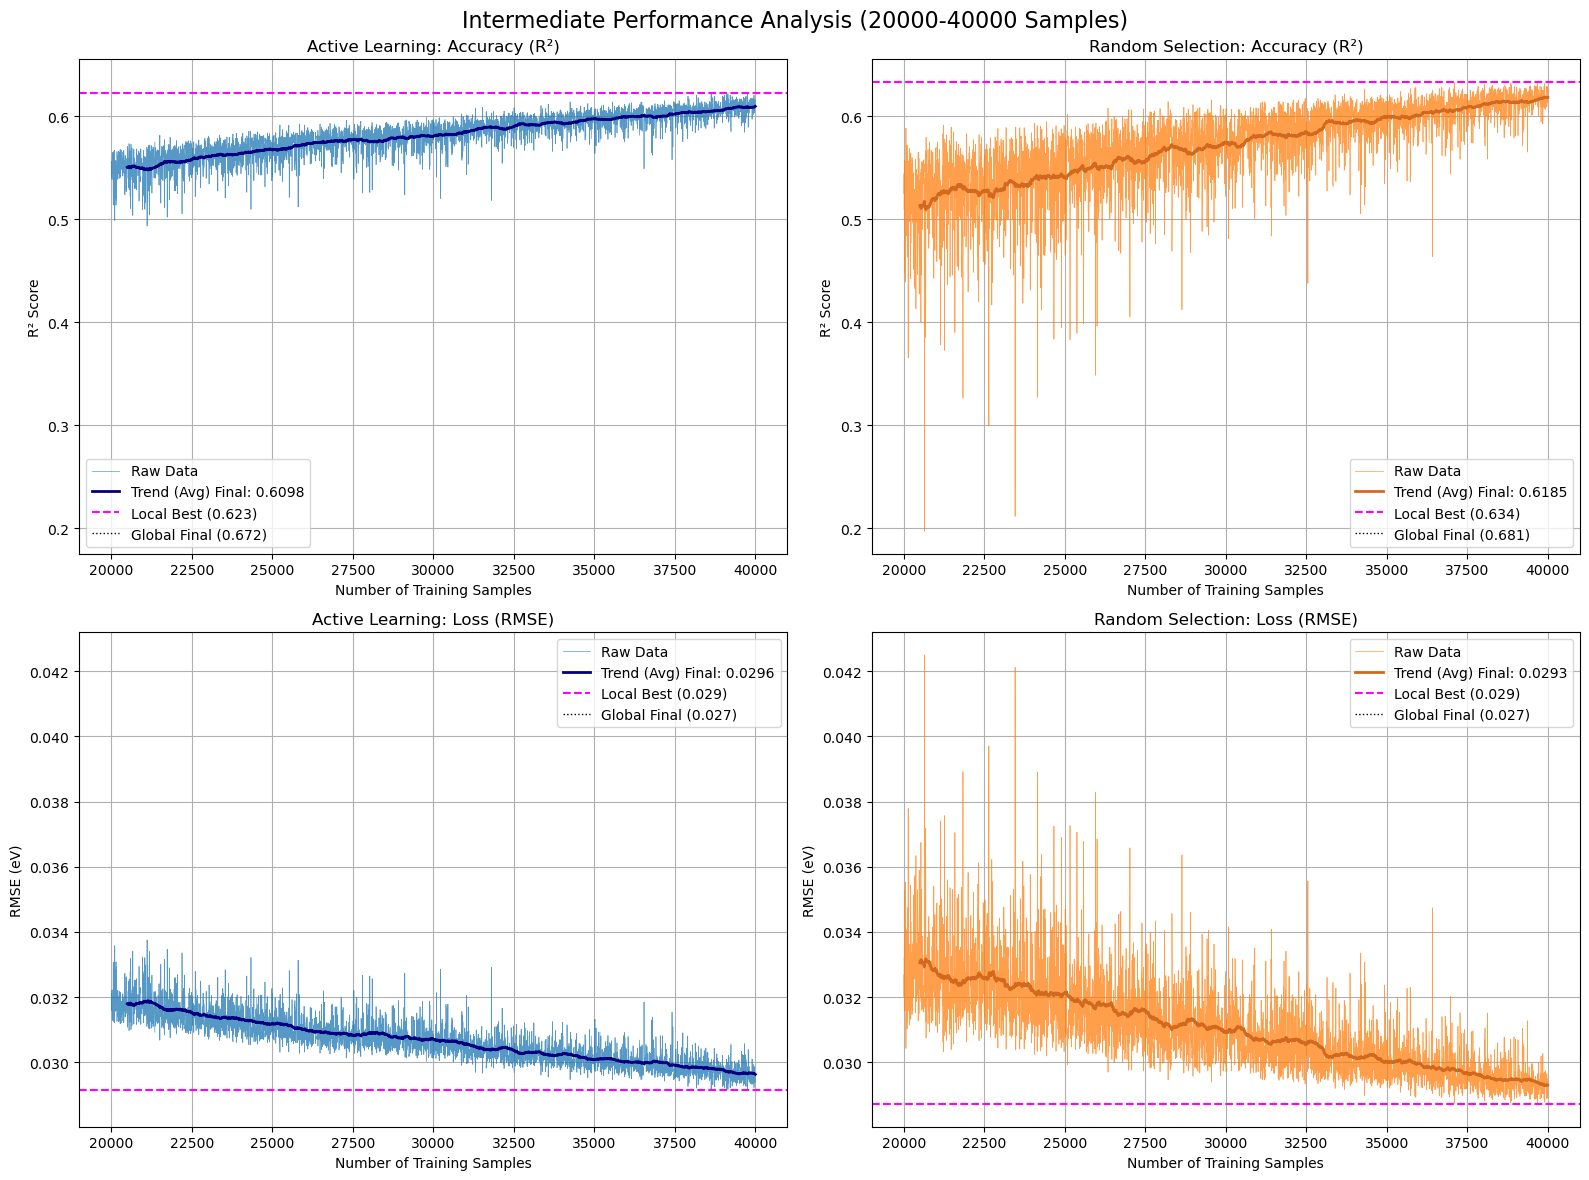

In [ ]:
# --- Late Stage Analysis (40k - 100k Samples) ---

zoom_start = 40000
zoom_end = 100000
smooth_window = 100  # Janela para suavização da tendência

# Get Global Final Values (End of Experiment)
final_r2_active = results_active_df['test_r2'].iloc[-1]
final_rmse_active = results_active_df['test_rmse'].iloc[-1]
final_r2_random = results_random_df['test_r2'].iloc[-1]
final_rmse_random = results_random_df['test_rmse'].iloc[-1]

# Filter data for the specific window
active_window = results_active_df[(results_active_df['n_samples'] >= zoom_start) & (results_active_df['n_samples'] <= zoom_end)].copy()
random_window = results_random_df[(results_random_df['n_samples'] >= zoom_start) & (results_random_df['n_samples'] <= zoom_end)].copy()

if not active_window.empty:
    active_window['r2_smooth'] = active_window['test_r2'].rolling(window=smooth_window).mean()
    active_window['rmse_smooth'] = active_window['test_rmse'].rolling(window=smooth_window).mean()

if not random_window.empty:
    random_window['r2_smooth'] = random_window['test_r2'].rolling(window=smooth_window).mean()
    random_window['rmse_smooth'] = random_window['test_rmse'].rolling(window=smooth_window).mean()

# Get Local Best Values (Within Window)
# Handle empty window case just in case
if not active_window.empty:
    local_best_r2_active = active_window['test_r2'].max()
    local_best_rmse_active = active_window['test_rmse'].min()
else:
    local_best_r2_active = 0
    local_best_rmse_active = 0

if not random_window.empty:
    local_best_r2_random = random_window['test_r2'].max()
    local_best_rmse_random = random_window['test_rmse'].min()
else:
    local_best_r2_random = 0
    local_best_rmse_random = 0

# Determine Common Y-Limits for Comparison
# R2 Limits
r2_min = min(active_window['test_r2'].min(), random_window['test_r2'].min())
r2_max = max(active_window['test_r2'].max(), random_window['test_r2'].max())
r2_margin = (r2_max - r2_min) * 0.05
r2_ylim = (r2_min - r2_margin, r2_max + r2_margin)

# RMSE Limits
rmse_min = min(active_window['test_rmse'].min(), random_window['test_rmse'].min())
rmse_max = max(active_window['test_rmse'].max(), random_window['test_rmse'].max())
rmse_margin = (rmse_max - rmse_min) * 0.05
rmse_ylim = (rmse_min - rmse_margin, rmse_max + rmse_margin)

print(f"Window Analysis ({zoom_start} to {zoom_end} samples):")
print(f"Active Learning Local Best: R²={local_best_r2_active:.4f} | RMSE={local_best_rmse_active:.4f}")
print(f"Random Selection Local Best: R²={local_best_r2_random:.4f} | RMSE={local_best_rmse_random:.4f}")
print("-" * 40)
print(f"Global Final Values: AL R²={final_r2_active:.4f} | Random R²={final_r2_random:.4f}")

# Create plots - 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'Late Stage Performance Analysis ({zoom_start}-{zoom_end} Samples)', fontsize=16)

# --- R² Scores ---

# Active Learning R²
if not active_window.empty:
    last_trend = active_window['r2_smooth'].iloc[-1]
    sns.lineplot(data=active_window, x='n_samples', y='test_r2', color='tab:blue', ax=axes[0, 0], marker=None, linewidth=0.5, alpha=0.75, label='Raw Data')
    sns.lineplot(data=active_window, x='n_samples', y='r2_smooth', color='navy', ax=axes[0, 0], marker=None, linewidth=2, label=f'Trend (Avg) Final: {last_trend:.4f}')
    axes[0, 0].axhline(y=local_best_r2_active, color='magenta', linestyle='--', label=f'Local Best ({local_best_r2_active:.3f})')
axes[0, 0].set_title('Active Learning: Accuracy (R²)')
axes[0, 0].set_xlabel('Number of Training Samples')
axes[0, 0].set_ylabel('R² Score')
axes[0, 0].set_ylim(r2_ylim)
axes[0, 0].grid(True)
axes[0, 0].axhline(y=final_r2_active, color='black', linestyle=':', linewidth=1, label=f'Global Final ({final_r2_active:.3f})')
axes[0, 0].legend()

# Random Selection R²
if not random_window.empty:
    last_trend = random_window['r2_smooth'].iloc[-1]
    sns.lineplot(data=random_window, x='n_samples', y='test_r2', color='tab:orange', ax=axes[0, 1], marker=None, linewidth=0.5, alpha=0.75, label='Raw Data')
    sns.lineplot(data=random_window, x='n_samples', y='r2_smooth', color='chocolate', ax=axes[0, 1], marker=None, linewidth=2, label=f'Trend (Avg) Final: {last_trend:.4f}')
    axes[0, 1].axhline(y=local_best_r2_random, color='magenta', linestyle='--', label=f'Local Best ({local_best_r2_random:.3f})')
axes[0, 1].set_title('Random Selection: Accuracy (R²)')
axes[0, 1].set_xlabel('Number of Training Samples')
axes[0, 1].set_ylabel('R² Score')
axes[0, 1].set_ylim(r2_ylim)
axes[0, 1].grid(True)
axes[0, 1].axhline(y=final_r2_random, color='black', linestyle=':', linewidth=1, label=f'Global Final ({final_r2_random:.3f})')
axes[0, 1].legend()

# --- RMSE Loss ---

# Active Learning RMSE
if not active_window.empty:
    last_trend = active_window['rmse_smooth'].iloc[-1]
    sns.lineplot(data=active_window, x='n_samples', y='test_rmse', color='tab:blue', ax=axes[1, 0], marker=None, linewidth=0.5, alpha=0.75, label='Raw Data')
    sns.lineplot(data=active_window, x='n_samples', y='rmse_smooth', color='navy', ax=axes[1, 0], marker=None, linewidth=2, label=f'Trend (Avg) Final: {last_trend:.4f}')
    axes[1, 0].axhline(y=local_best_rmse_active, color='magenta', linestyle='--', label=f'Local Best ({local_best_rmse_active:.3f})')
axes[1, 0].set_title('Active Learning: Loss (RMSE)')
axes[1, 0].set_xlabel('Number of Training Samples')
axes[1, 0].set_ylabel('RMSE (eV)')
axes[1, 0].set_ylim(rmse_ylim)
axes[1, 0].grid(True)
axes[1, 0].axhline(y=final_rmse_active, color='black', linestyle=':', linewidth=1, label=f'Global Final ({final_rmse_active:.3f})')
axes[1, 0].legend()

# Random Selection RMSE
if not random_window.empty:
    last_trend = random_window['rmse_smooth'].iloc[-1]
    sns.lineplot(data=random_window, x='n_samples', y='test_rmse', color='tab:orange', ax=axes[1, 1], marker=None, linewidth=0.5, alpha=0.75, label='Raw Data')
    sns.lineplot(data=random_window, x='n_samples', y='rmse_smooth', color='chocolate', ax=axes[1, 1], marker=None, linewidth=2, label=f'Trend (Avg) Final: {last_trend:.4f}')
    axes[1, 1].axhline(y=local_best_rmse_random, color='magenta', linestyle='--', label=f'Local Best ({local_best_rmse_random:.3f})')
axes[1, 1].set_title('Random Selection: Loss (RMSE)')
axes[1, 1].set_xlabel('Number of Training Samples')
axes[1, 1].set_ylabel('RMSE (eV)')
axes[1, 1].set_ylim(rmse_ylim)
axes[1, 1].grid(True)
axes[1, 1].axhline(y=final_rmse_random, color='black', linestyle=':', linewidth=1, label=f'Global Final ({final_rmse_random:.3f})')
axes[1, 1].legend()

plt.tight_layout()
plt.show()